### 📌 Célula 1 — Imports e conexão

In [2]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from datetime import datetime
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Caminho relativo para o banco
DB_PATH = "../database/totem.db"

conn = sqlite3.connect(DB_PATH)
df = pd.read_sql_query("SELECT * FROM interactions", conn)
conn.close()

df.head()

,id,timestamp,presence,touch,voice_detected,duration
0,1,2025-11-22T14:33:34,0,0,0,0
1,2,2025-11-22T14:33:39,0,0,0,0
2,3,2025-11-22T14:33:44,1,0,0,4
3,4,2025-11-22T14:33:49,1,1,1,18
4,5,2025-11-22T14:33:54,0,0,0,0


### 📌 Célula 2 — Conversão de tipos e limpeza básica

In [3]:
# Converte timestamp para datetime
df["timestamp"] = pd.to_datetime(df["timestamp"])

# Ordena por tempo
df = df.sort_values("timestamp").reset_index(drop=True)

# Remove duplicados (se houver)
df = df.drop_duplicates(subset=["timestamp", "presence", "touch", "voice_detected", "duration"])

# Filtra registros com duration negativa (não deveria existir), apenas por segurança
df = df[df["duration"] >= 0].copy()

df.describe()

,id,timestamp,presence,touch,voice_detected,duration
count,371.000000,371,371.000000,371.000000,371.000000,371.000000
mean,186.000000,2025-11-22 14:53:44.371968,0.487871,0.207547,0.218329,5.145553
min,1.000000,2025-11-22 14:33:34,0.000000,0.000000,0.000000,0.000000
25%,93.500000,2025-11-22 14:41:17.500000,0.000000,0.000000,0.000000,0.000000
50%,186.000000,2025-11-22 14:49:01,0.000000,0.000000,0.000000,0.000000
75%,278.500000,2025-11-22 15:07:29.500000,1.000000,0.000000,0.000000,10.000000
max,371.000000,2025-11-22 15:15:13,1.000000,1.000000,1.000000,20.000000
std,107.242715,NaN,0.500528,0.406098,0.413670,6.572700


📌 Célula 3 — Feature engineering e métricas descritivas

In [4]:
# Cria coluna categórica simples: se houve interação real ou não
df["houve_interacao"] = df["presence"].apply(lambda x: "sim" if x == 1 else "nao")

# Classificação simples de tipo de interação baseada na duração
def classificar_interacao(dur):
    if dur == 0:
        return "sem_interacao"
    elif dur < 5:
        return "rapida"
    elif dur <= 12:
        return "media"
    else:
        return "longa"

df["tipo_interacao"] = df["duration"].apply(classificar_interacao)

display(df.head())

print("Total de registros:", len(df))
print("Total de ativações (presence = 1):", df["presence"].sum())
print("Tempo médio de permanência (segundos):", df["duration"].mean())


,id,timestamp,presence,touch,voice_detected,duration,houve_interacao,tipo_interacao
0,1,2025-11-22 14:33:34,0,0,0,0,nao,sem_interacao
1,2,2025-11-22 14:33:39,0,0,0,0,nao,sem_interacao
2,3,2025-11-22 14:33:44,1,0,0,4,sim,rapida
3,4,2025-11-22 14:33:49,1,1,1,18,sim,longa
4,5,2025-11-22 14:33:54,0,0,0,0,nao,sem_interacao


Total de registros: 371
Total de ativações (presence = 1): 181
Tempo médio de permanência (segundos): 5.1455525606469


📌 Célula 4 — Análises por horário e gráficos básicos

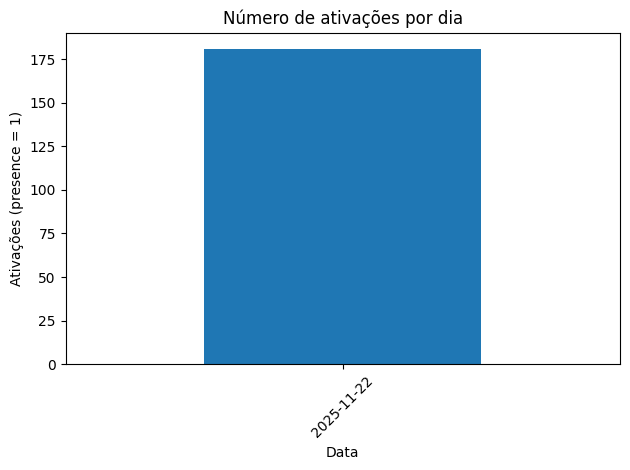

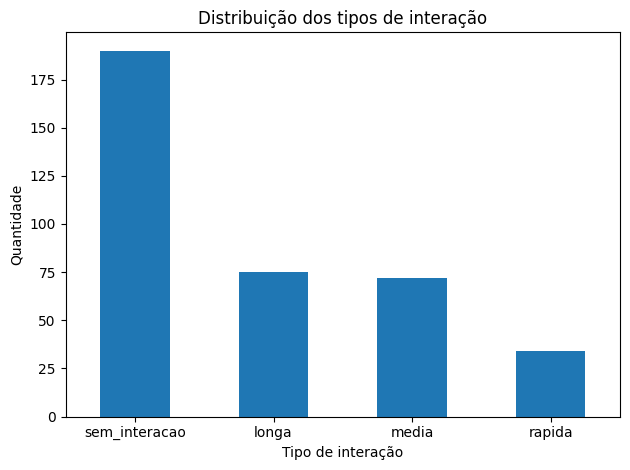

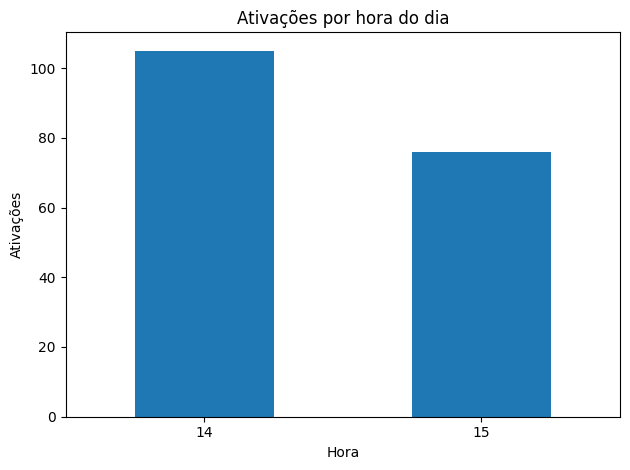

In [5]:
# Cria colunas de data e hora para análises temporais
df["data"] = df["timestamp"].dt.date
df["hora"] = df["timestamp"].dt.hour

# Volume diário de interações
interacoes_por_dia = df.groupby("data")["presence"].sum()

plt.figure()
interacoes_por_dia.plot(kind="bar")
plt.title("Número de ativações por dia")
plt.xlabel("Data")
plt.ylabel("Ativações (presence = 1)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Distribuição por tipo de interação
tipos = df["tipo_interacao"].value_counts()

plt.figure()
tipos.plot(kind="bar")
plt.title("Distribuição dos tipos de interação")
plt.xlabel("Tipo de interação")
plt.ylabel("Quantidade")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Horário de pico (considerando qualquer presença)
interacoes_por_hora = df.groupby("hora")["presence"].sum()

plt.figure()
interacoes_por_hora.plot(kind="bar")
plt.title("Ativações por hora do dia")
plt.xlabel("Hora")
plt.ylabel("Ativações")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


📌 Célula 5 — Modelo de Machine Learning supervisionado

In [6]:
# Para ML vamos prever se a interação será "rapida" ou "nao_rapida"
df_ml = df.copy()

df_ml["alvo"] = df_ml["duration"].apply(lambda x: "rapida" if 0 < x < 5 else "nao_rapida")

# Remove linhas sem interação (duration = 0) se quiser deixar o modelo mais limpo
df_ml = df_ml[df_ml["duration"] > 0].copy()

# Features simples
X = df_ml[["presence", "touch", "voice_detected", "duration"]]
y = df_ml["alvo"]

if len(df_ml) > 5:
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42
    )

    modelo = RandomForestClassifier(random_state=42)
    modelo.fit(X_train, y_train)

    y_pred = modelo.predict(X_test)

    print("Relatório de classificação:\n")
    print(classification_report(y_test, y_pred))

    print("Matriz de confusão:\n")
    print(confusion_matrix(y_test, y_pred))
else:
    print("Ainda há poucos dados para treinar um modelo (registre mais interações).")


Relatório de classificação:

              precision    recall  f1-score   support

  nao_rapida       1.00      1.00      1.00        43
      rapida       1.00      1.00      1.00        12

    accuracy                           1.00        55
   macro avg       1.00      1.00      1.00        55
weighted avg       1.00      1.00      1.00        55

Matriz de confusão:

[[43  0]
 [ 0 12]]


📌 Célula 6 — Salvando um resumo para o dashboard

In [7]:
# Exemplo de agregação para exportar se quiser
resumo_por_dia = df.groupby("data").agg(
    ativacoes=("presence", "sum"),
    media_duracao=("duration", "mean")
).reset_index()

resumo_por_dia


,data,ativacoes,media_duracao
0,2025-11-22,181,5.145553
